# Standard Stars and CalSpec

Standard stars are essential for flux calibration of IFS observations.
`slicersim` provides direct access to the HST **CalSpec** catalog through `LazuliCalSpec`,
letting you simulate observations of any catalog star and estimate the required exposure time
for a given calibration quality.

This notebook shows:
- How to load a CalSpec star by name
- How to inspect and plot its spectrum
- How to set observing conditions and get a realistic simulated spectrum
- How to compare several standard stars

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. Loading a star and listing the available CalSpec sources

Pass the short name of any CalSpec star to `LazuliCalSpec`. The `source_names` property
lists all the stars of the catalog.

In [2]:
# Load the white dwarf GD71, a classic flux calibrator
star = slicersim.LazuliCalSpec("gd71")

# List the available names (unique, non-empty)
names = [name for name in dict.fromkeys(star.source_names) if name]
print(f"{len(names)} stars available. First 20:")
print(names[:20])

160 stars available. First 20:
['109vir', '10lac', '16cygb', '1732526', '1740346', '1743045', '1757132', '1802271', '1805292', '1808347', '1812095', '1812524', '18sco', '2m003618', '2m055914', 'agk_81d266', 'alpha_lyr', 'bd02d3375', 'bd11d3759', 'bd21d0607']


***
## 2. Inspecting the spectrum

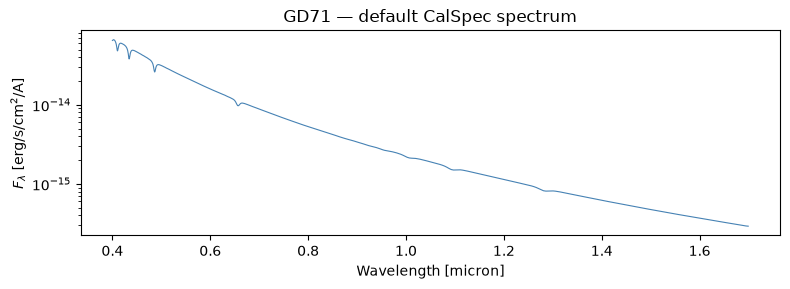

In [3]:
# Default spectrum (no noise, flux-calibrated)
lbda, flux, variance = star.get_spectrum(unit="flambda", incl_error=False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lbda / 1e4, flux, lw=0.8, color="steelblue")
ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("GD71 — default CalSpec spectrum")
ax.set_yscale("log")
plt.tight_layout()

***
## 3. Setting the apparent magnitude

By default, CalSpec spectra are used at their measured (HST-calibrated) flux level.
Use `change_properties()` to rescale them to any apparent magnitude, e.g. to model
a fainter calibrator.

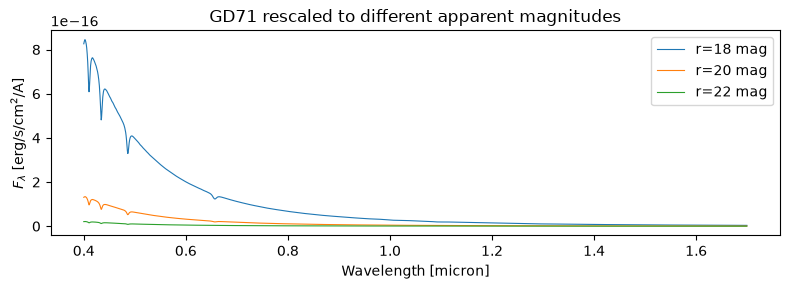

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for mag in [18, 20, 22]:
    star.change_properties(mag=mag, band="sdssr")
    lbda, flux, _ = star.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda / 1e4, flux, lw=0.8, label=f"r={mag} mag")

ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("GD71 rescaled to different apparent magnitudes")
ax.legend()
plt.tight_layout()

***
## 4. Exposure time for a calibration observation

How long does it take to get a well-measured spectrum of a faint standard star?
We ask for an average SNR of 50 per resolution element between 6000 and 9000 Å,
typical for a useful flux calibrator.

In [5]:
# Rescale to mag=20 in sdss-r
star.change_properties(mag=20, band="sdssr")

_ = star.setup_to_snr(50, per_resolution=True, lbda_range=[6000, 9000])

exptime = star.get_exposure_time()
cfg = star.get_readout_config()
print(f"Exposure time : {exptime:.1f} s  ({exptime/60:.1f} min)")
print(f"Readout mode  : nmd={cfg['nmd']},  nramps={cfg['nramps']}")

Exposure time : 1290.5 s  (21.5 min)
Readout mode  : nmd=(57, 8, 0),  nramps=1


***
## 5. Realistic simulated spectrum

Once the readout is configured, `get_spectrum()` returns the flux and its variance.
Drawing a random realisation gives you what the pipeline would actually receive.

The SNR per wavelength bin is `flux / sqrt(variance)`; the SNR per resolution element is
larger by a factor `sqrt(dispersion_resolution)`, since a resolution element spans
`dispersion_resolution` wavelength bins.

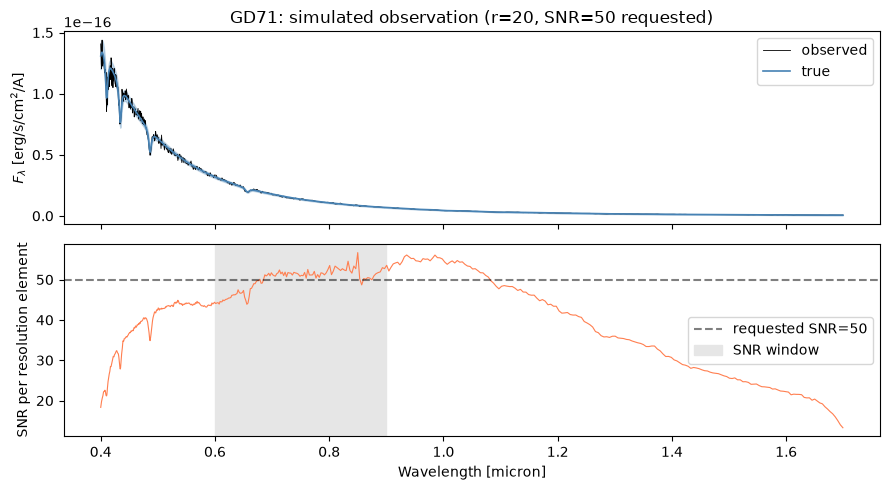

In [6]:
lbda, flux_true, variance = star.get_spectrum(unit="flambda", incl_error=False)
flux_obs = np.random.normal(loc=flux_true, scale=np.sqrt(variance))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax1.plot(lbda / 1e4, flux_obs, lw=0.6, color="k", label="observed")
ax1.plot(lbda / 1e4, flux_true, lw=1.2, color="steelblue", label="true")
ax1.fill_between(lbda / 1e4,
                 flux_true - np.sqrt(variance),
                 flux_true + np.sqrt(variance),
                 alpha=0.3, color="steelblue")
ax1.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax1.legend()
ax1.set_title("GD71: simulated observation (r=20, SNR=50 requested)")

# SNR per resolution element
dispersion_resolution = star.simulation.spectrograph.dispersion_resolution
snr = flux_true / np.sqrt(variance) * np.sqrt(dispersion_resolution)
ax2.plot(lbda / 1e4, snr, lw=0.8, color="coral")
ax2.axhline(50, ls="--", color="k", alpha=0.5, label="requested SNR=50")
ax2.axvspan(0.6, 0.9, color="0.9", zorder=0, label="SNR window")
ax2.set_xlabel("Wavelength [micron]")
ax2.set_ylabel("SNR per resolution element")
ax2.legend()

plt.tight_layout()

***
## 6. Comparing several standard stars

Different CalSpec stars have very different spectral shapes. Here we compare the
hot DA white dwarf GD71, the solar-analog G-type star P177D, and the hot subdwarf Feige 110.

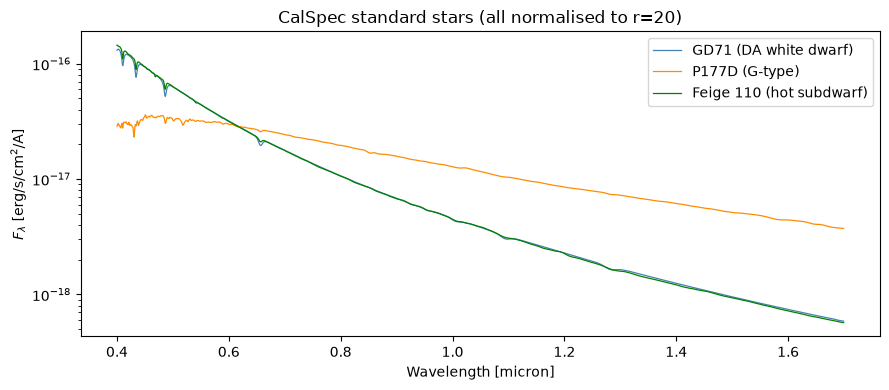

In [7]:
star_names = ["gd71", "p177d", "feige110"]
labels     = ["GD71 (DA white dwarf)", "P177D (G-type)", "Feige 110 (hot subdwarf)"]
colors     = ["steelblue", "darkorange", "green"]

fig, ax = plt.subplots(figsize=(9, 4))

for name, label, color in zip(star_names, labels, colors):
    s = slicersim.LazuliCalSpec(name)
    # normalise to r=20 for a fair spectral-shape comparison
    s.change_properties(mag=20, band="sdssr")
    lbda, flux, _ = s.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda / 1e4, flux, lw=0.9, color=color, label=label)

ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("CalSpec standard stars (all normalised to r=20)")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()

Hot stars like GD71 and Feige 110 have smooth, blue spectra with few features (mostly
hydrogen and helium lines), which makes them convenient flux calibrators. Being blue,
however, they deliver less flux in the near-infrared part of Lazuli's wavelength range than
cooler stars like P177D.

***
## 7. Exposure time as a function of magnitude

A quick scan to estimate the calibration overhead for standard stars of different brightnesses.

CPU times: user 3.64 s, sys: 1.89 s, total: 5.52 s
Wall time: 5.83 s


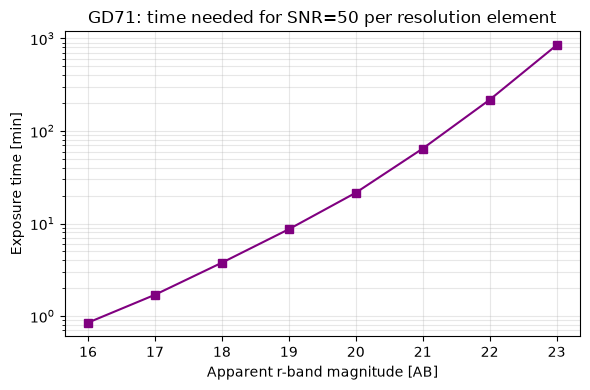

In [8]:
%%time
mags = np.arange(16, 24)
exptimes = []

for mag in mags:
    s = slicersim.LazuliCalSpec("gd71")
    s.change_properties(mag=float(mag), band="sdssr")
    _ = s.setup_to_snr(50, per_resolution=True, lbda_range=[6000, 9000])
    exptimes.append(s.get_exposure_time() / 60)  # minutes

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(mags, exptimes, "s-", color="purple")
ax.set_xlabel("Apparent r-band magnitude [AB]")
ax.set_ylabel("Exposure time [min]")
ax.set_title("GD71: time needed for SNR=50 per resolution element")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()